# 119番通報 緊急度判定プロトコル — 遷移図

`transition_diagram/protocol.yaml` から症候別の遷移図を Graphviz で生成します。

**レイアウトの取り決め**

| 形状 | 意味 |
|---|---|
| ◇ ひし形 | 選択肢を持つ判定ノード（質問） |
| ▱ 平行四辺形 | 情報収集ノード（`metadata_only`、緊急度に影響しない） |
| ⬭ 楕円 | トリアージ確定ノード（葉） |
| ⬜ 帯状 | 外部プロトコル・外部フローへのルーティング先 |
| 付箋 | プロトコルの fallback ルール |

**色（トリアージ）**

- 赤: R1 / R2 / R3（Very urgent）
- 黄: Y1 / Y2（Semi-urgent）
- 緑: G（Low urgency）

## 1. セットアップ

In [7]:
from pathlib import Path

import yaml
from graphviz import Digraph
from IPython.display import Markdown, display

YAML_PATH = Path("protocol.yaml")
with YAML_PATH.open(encoding="utf-8") as f:
    data = yaml.safe_load(f)

labels = data["labels"]
entry_flow = {n["id"]: n for n in data["entry_flow"]}
common_vitals = {n["id"]: n for n in data["common_vitals"]}
router = data["chief_complaint_router"]
protocols = {p["id"]: p for p in data["protocols"]}

print(f"YAML: {YAML_PATH.resolve()}")
print(f"プロトコル数: {len(protocols)}")
print(f"共通バイタルノード数: {len(common_vitals)}")
print("プロトコル一覧:")
for pid, p in protocols.items():
    print(f"  - {pid}: {p.get('name', '')}")

YAML: C:\Users\hiyok\Desktop\Emergency_task\transition_diagram\protocol.yaml
プロトコル数: 22
共通バイタルノード数: 6
プロトコル一覧:
  - dyspnea: 呼吸困難
  - palpitation: 動悸
  - consciousness_disorder_syncope: 意識障害／失神
  - convulsion: けいれん
  - headache: 頭痛
  - chest_pain_nontraumatic: 胸痛（非外傷性）
  - back_pain: 背部痛
  - lumbar_pain: 腰部痛
  - adult_fever: 成人の発熱（16歳以上）
  - abdominal_pain: 腹痛
  - adult_nausea_vomiting: 成人の嘔気・嘔吐（16歳以上）
  - dizziness: めまい
  - numbness: しびれ
  - hematemesis_hemoptysis: 吐血・喀血
  - melena_hematochezia: 下血・血便
  - malaise: 具合が悪い・気分が悪い
  - trauma: 外傷
  - foreign_body_ingestion: 固形物誤飲
  - poisoning: 中毒
  - pediatric_fever: 小児の発熱（16歳未満）
  - pediatric_nausea_vomiting: 小児の嘔気・嘔吐（16歳未満）
  - pediatric_head_neck_trauma: 小児の頭・頸部外傷（16歳未満）


## 2. 描画ヘルパー

In [8]:
TRIAGE_FILL = {
    "R1": "#e74c3c", "R2": "#e74c3c", "R3": "#c0392b",
    "Y1": "#f1c40f", "Y2": "#f4d03f",
    "G": "#27ae60",
}
TRIAGE_FONT = {
    "R1": "white", "R2": "white", "R3": "white",
    "Y1": "black", "Y2": "black",
    "G": "white",
}

FONT = "Hiragino Sans"


def _trim(text: str, n: int = 28) -> str:
    text = (text or "").replace("\n", " ").strip()
    return text if len(text) <= n else text[: n - 1] + "…"


def _new_graph(title: str) -> Digraph:
    g = Digraph()
    g.attr(
        rankdir="TB",
        label=title,
        labelloc="t",
        fontname=FONT,
        fontsize="16",
        splines="spline",
        nodesep="0.35",
        ranksep="0.45",
    )
    g.attr("node", fontname=FONT, fontsize="11", margin="0.12,0.06")
    g.attr("edge", fontname=FONT, fontsize="9")
    return g


def _terminal(g: Digraph, parent: str, edge_label: str, triage: str, oral=None):
    tid = f"__term_{parent}_{len(g.body)}"
    text = triage
    if oral:
        text += "\n口頭指導: " + ", ".join(oral)
    g.node(
        tid,
        text,
        shape="ellipse",
        style="filled,bold",
        fillcolor=TRIAGE_FILL.get(triage, "#bdc3c7"),
        fontcolor=TRIAGE_FONT.get(triage, "black"),
    )
    g.edge(parent, tid, label=_trim(edge_label, 16))


def _question_node(g: Digraph, nid: str, question: str, fill="#fdf2e9"):
    g.node(nid, _trim(question, 30), shape="diamond", style="filled", fillcolor=fill)


def _info_node(g: Digraph, nid: str, question: str):
    g.node(
        nid,
        "[情報収集]\n" + _trim(question, 28),
        shape="parallelogram",
        style="filled",
        fillcolor="#d6eaf8",
    )


def _route_node(g: Digraph, tgt_id: str, label: str):
    g.node(tgt_id, label, shape="cds", style="filled,dashed", fillcolor="#fadbd8")


def _add_choices(g: Digraph, parent: str, choices):
    for ch in choices or []:
        etext = ch.get("text") or ch.get("value") or ch.get("code") or ""
        if ch.get("triage"):
            _terminal(g, parent, etext, ch["triage"], ch.get("oral_instruction"))
        if ch.get("next"):
            g.edge(parent, ch["next"], label=_trim(etext, 16))
        if ch.get("route_to_protocol"):
            tgt = f"__proto_{ch['route_to_protocol']}"
            _route_node(g, tgt, f"→ {ch['route_to_protocol']}")
            g.edge(parent, tgt, label=_trim(etext, 16))
        if ch.get("route_to"):
            tgt = f"__route_{ch['route_to']}"
            _route_node(g, tgt, ch["route_to"])
            g.edge(parent, tgt, label=_trim(etext, 16))
        if ch.get("followup_metadata"):
            g.edge(parent, ch["followup_metadata"], label="followup")

## 3. 導入フロー：エントリ → 共通バイタル → 主訴ルーター


(process:30628): Pango-WARNING **: 22:28:06.007: couldn't load font "Hiragino Sans Not-Rotated 16", falling back to "Sans Not-Rotated 16", expect ugly output.

(process:30628): Pango-WARNING **: 22:28:06.065: couldn't load font "Hiragino Sans Not-Rotated 11", falling back to "Sans Not-Rotated 11", expect ugly output.

(process:30628): Pango-WARNING **: 22:28:06.097: couldn't load font "Hiragino Sans Not-Rotated 9", falling back to "Sans Not-Rotated 9", expect ugly output.


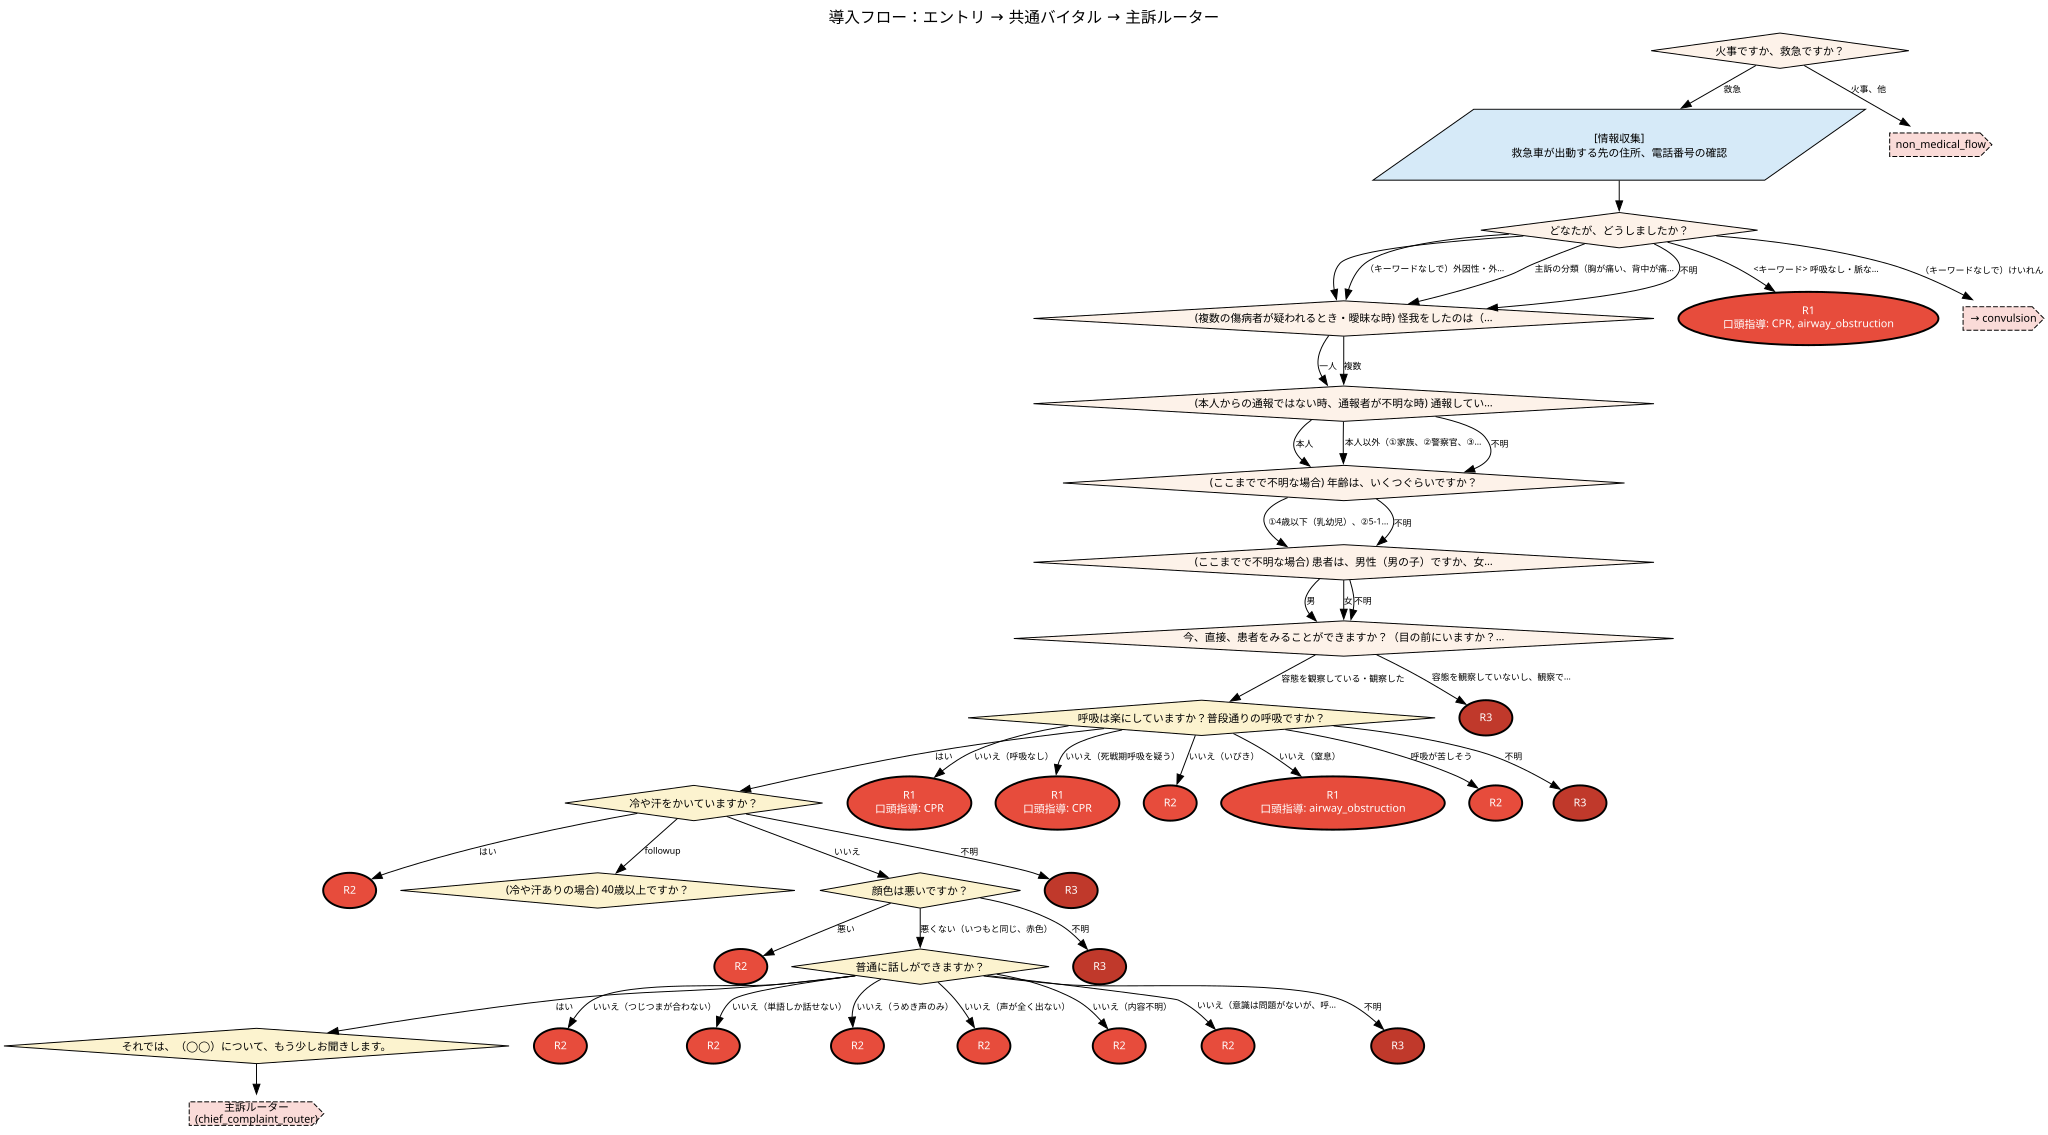

In [9]:
def render_common_flow() -> Digraph:
    g = _new_graph("導入フロー：エントリ → 共通バイタル → 主訴ルーター")

    for nid, node in entry_flow.items():
        q = node.get("question", nid)
        if node.get("metadata_only") or node.get("transition_only"):
            _info_node(g, nid, q)
        else:
            _question_node(g, nid, q)
        if node.get("next"):
            g.edge(nid, node["next"])
        _add_choices(g, nid, node.get("choices"))

    for nid, node in common_vitals.items():
        q = node.get("question", nid)
        _question_node(g, nid, q, fill="#fcf3cf")
        if node.get("next"):
            g.edge(nid, node["next"])
        _add_choices(g, nid, node.get("choices"))

    _route_node(g, "chief_complaint_router", "主訴ルーター\n(chief_complaint_router)")
    return g


display(render_common_flow())

## 4. 主訴ルーター（症候 → プロトコル）


(process:19976): Pango-WARNING **: 22:28:07.228: couldn't load font "Hiragino Sans Not-Rotated 16", falling back to "Sans Not-Rotated 16", expect ugly output.

(process:19976): Pango-WARNING **: 22:28:07.264: couldn't load font "Hiragino Sans Not-Rotated 11", falling back to "Sans Not-Rotated 11", expect ugly output.

(process:19976): Pango-WARNING **: 22:28:07.275: couldn't load font "Hiragino Sans Not-Rotated 9", falling back to "Sans Not-Rotated 9", expect ugly output.


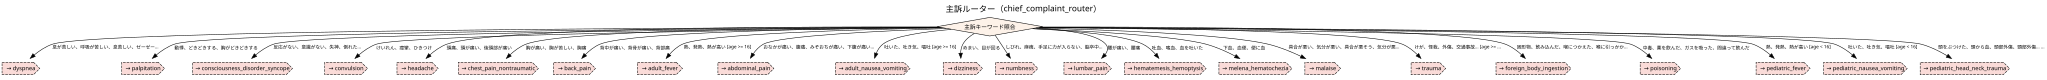

In [10]:
def render_router() -> Digraph:
    g = _new_graph("主訴ルーター（chief_complaint_router）")
    g.node("__router", "主訴キーワード照合", shape="diamond", style="filled", fillcolor="#fdf2e9")
    for r in router["routes"]:
        pid = r["protocol"]
        kws = "、".join(r.get("match_any", [])[:4])
        if len(r.get("match_any", [])) > 4:
            kws += "…"
        cond = r.get("age_condition")
        edge_label = kws + (f"\n[{cond}]" if cond else "")
        tgt = f"__proto_{pid}"
        _route_node(g, tgt, f"→ {pid}")
        g.edge("__router", tgt, label=_trim(edge_label, 24))
    return g


display(render_router())

## 5. 症候別プロトコル

In [11]:
def render_protocol(pid: str, include_common_vitals: bool = False) -> Digraph:
    proto = protocols[pid]
    title = f"{proto.get('name', '')}  ({pid})"
    if proto.get("source_pages"):
        title += f"  — pp.{','.join(map(str, proto['source_pages']))}"
    g = _new_graph(title)

    entry = f"__entry_{pid}"
    if proto.get("start_after_common_vitals"):
        g.node(entry, "共通バイタル後", shape="cds", style="filled", fillcolor="#ecf0f1")
    else:
        g.node(entry, "開始", shape="circle", style="filled", fillcolor="#ecf0f1")

    if include_common_vitals and "common_vitals" in (proto.get("inherits") or []):
        for nid, node in common_vitals.items():
            _question_node(g, nid, node.get("question", nid), fill="#fcf3cf")
            if node.get("next"):
                g.edge(nid, node["next"])
            _add_choices(g, nid, node.get("choices"))
        if "route_to_symptom_inquiry" in common_vitals:
            g.edge(entry, "common_breathing")
            g.edge("route_to_symptom_inquiry", proto.get("start_node") or proto.get("nodes", [{}])[0].get("id"), label=f"→ {pid}")

    nodes = proto.get("nodes", [])
    if nodes and not include_common_vitals:
        g.edge(entry, proto.get("start_node") or nodes[0]["id"])

    for node in nodes:
        nid = node["id"]
        q = node.get("question", nid)

        if node.get("triage") and not node.get("choices"):
            t = node["triage"]
            g.node(
                nid,
                _trim(q, 30) + f"\n→ {t}",
                shape="ellipse",
                style="filled,bold",
                fillcolor=TRIAGE_FILL.get(t, "#bdc3c7"),
                fontcolor=TRIAGE_FONT.get(t, "black"),
            )
            continue

        if node.get("metadata_only") or node.get("transition_only"):
            _info_node(g, nid, q)
        else:
            _question_node(g, nid, q)
        if node.get("next"):
            g.edge(nid, node["next"])
        _add_choices(g, nid, node.get("choices"))

    followups = proto.get("terminal_followup_chain") or []
    for src, dst in zip(followups, followups[1:]):
        g.edge(src, dst, label="followup")

    fb = proto.get("fallback")
    if fb:
        parts = []
        if "if_any_unknown" in fb:
            parts.append(f"不明あり → {fb['if_any_unknown']}")
        if "if_all_symptom_questions_negative" in fb:
            parts.append(f"全て陰性 → {fb['if_all_symptom_questions_negative']}")
        g.node(f"__fb_{pid}", "fallback\n" + "\n".join(parts), shape="note", style="filled", fillcolor="#fdebd0")

    return g

### 5.1 個別表示

#### 呼吸困難 (`dyspnea`)


(process:33824): Pango-WARNING **: 22:28:08.678: couldn't load font "Hiragino Sans Not-Rotated 16", falling back to "Sans Not-Rotated 16", expect ugly output.

(process:33824): Pango-WARNING **: 22:28:08.719: couldn't load font "Hiragino Sans Not-Rotated 11", falling back to "Sans Not-Rotated 11", expect ugly output.

(process:33824): Pango-WARNING **: 22:28:08.734: couldn't load font "Hiragino Sans Not-Rotated 9", falling back to "Sans Not-Rotated 9", expect ugly output.


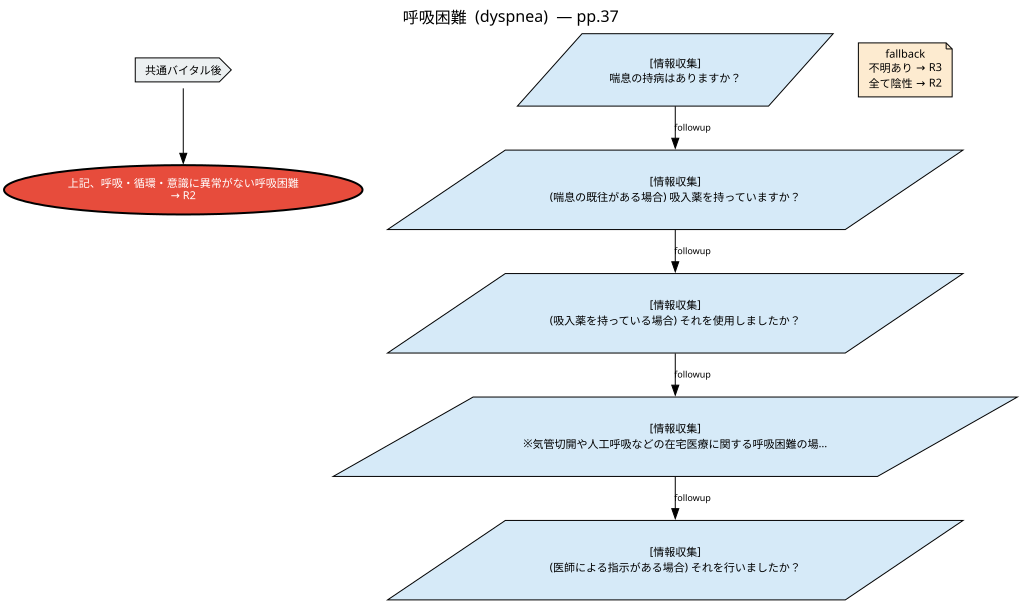

In [12]:
protocol_id = "dyspnea"

display(Markdown(f"#### {protocols[protocol_id].get('name', protocol_id)} (`{protocol_id}`)"))
display(render_protocol(protocol_id))

### 5.2 共通バイタル込みで表示

#### 共通バイタル込み: 呼吸困難 (`dyspnea`)


(process:32244): Pango-WARNING **: 22:28:09.699: couldn't load font "Hiragino Sans Not-Rotated 16", falling back to "Sans Not-Rotated 16", expect ugly output.

(process:32244): Pango-WARNING **: 22:28:09.732: couldn't load font "Hiragino Sans Not-Rotated 11", falling back to "Sans Not-Rotated 11", expect ugly output.

(process:32244): Pango-WARNING **: 22:28:09.755: couldn't load font "Hiragino Sans Not-Rotated 9", falling back to "Sans Not-Rotated 9", expect ugly output.


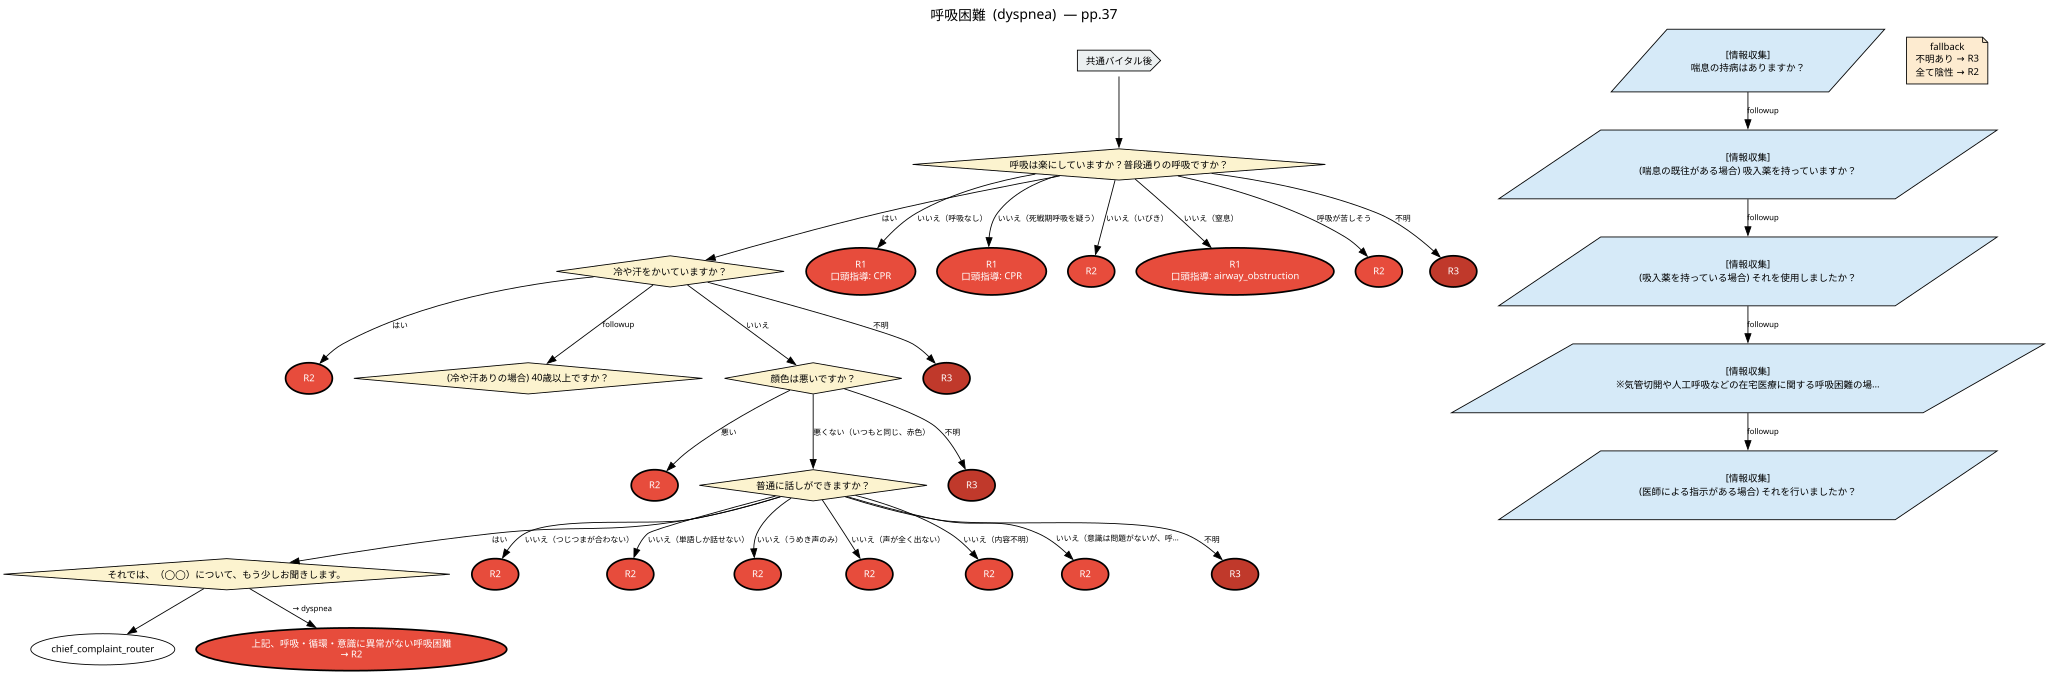

In [13]:
protocol_id = "dyspnea"

display(Markdown(f"#### 共通バイタル込み: {protocols[protocol_id].get('name', protocol_id)} (`{protocol_id}`)"))
display(render_protocol(protocol_id, include_common_vitals=True))

### 5.3 全プロトコル一括表示

#### 呼吸困難 (`dyspnea`)


(process:29344): Pango-WARNING **: 22:28:10.887: couldn't load font "Hiragino Sans Not-Rotated 16", falling back to "Sans Not-Rotated 16", expect ugly output.

(process:29344): Pango-WARNING **: 22:28:10.934: couldn't load font "Hiragino Sans Not-Rotated 11", falling back to "Sans Not-Rotated 11", expect ugly output.

(process:29344): Pango-WARNING **: 22:28:10.954: couldn't load font "Hiragino Sans Not-Rotated 9", falling back to "Sans Not-Rotated 9", expect ugly output.


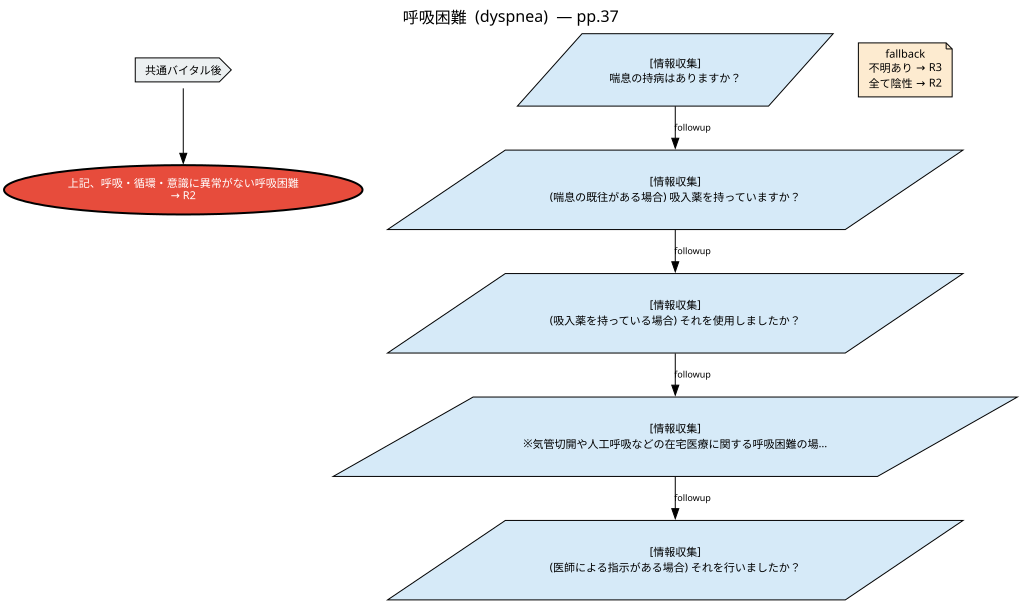

#### 動悸 (`palpitation`)


(process:34956): Pango-WARNING **: 22:28:11.893: couldn't load font "Hiragino Sans Not-Rotated 16", falling back to "Sans Not-Rotated 16", expect ugly output.

(process:34956): Pango-WARNING **: 22:28:11.930: couldn't load font "Hiragino Sans Not-Rotated 11", falling back to "Sans Not-Rotated 11", expect ugly output.

(process:34956): Pango-WARNING **: 22:28:11.951: couldn't load font "Hiragino Sans Not-Rotated 9", falling back to "Sans Not-Rotated 9", expect ugly output.


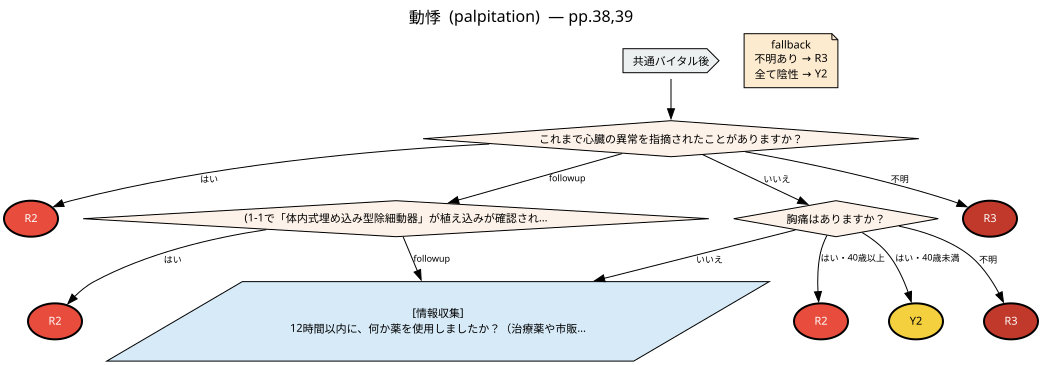

#### 意識障害／失神 (`consciousness_disorder_syncope`)


(process:33984): Pango-WARNING **: 22:28:12.989: couldn't load font "Hiragino Sans Not-Rotated 16", falling back to "Sans Not-Rotated 16", expect ugly output.

(process:33984): Pango-WARNING **: 22:28:13.022: couldn't load font "Hiragino Sans Not-Rotated 11", falling back to "Sans Not-Rotated 11", expect ugly output.

(process:33984): Pango-WARNING **: 22:28:13.045: couldn't load font "Hiragino Sans Not-Rotated 9", falling back to "Sans Not-Rotated 9", expect ugly output.


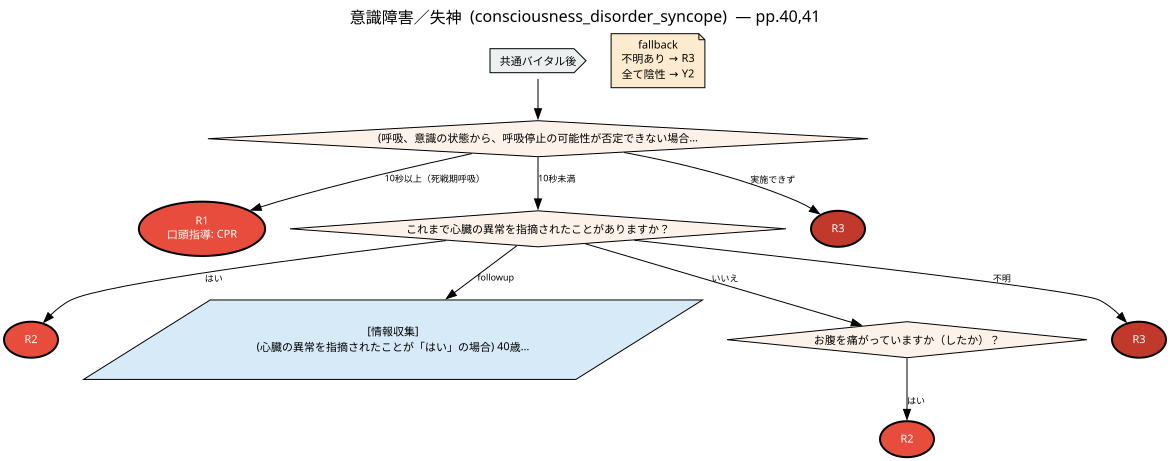

#### けいれん (`convulsion`)


(process:26768): Pango-WARNING **: 22:28:14.188: couldn't load font "Hiragino Sans Not-Rotated 16", falling back to "Sans Not-Rotated 16", expect ugly output.

(process:26768): Pango-WARNING **: 22:28:14.230: couldn't load font "Hiragino Sans Not-Rotated 11", falling back to "Sans Not-Rotated 11", expect ugly output.

(process:26768): Pango-WARNING **: 22:28:14.254: couldn't load font "Hiragino Sans Not-Rotated 9", falling back to "Sans Not-Rotated 9", expect ugly output.


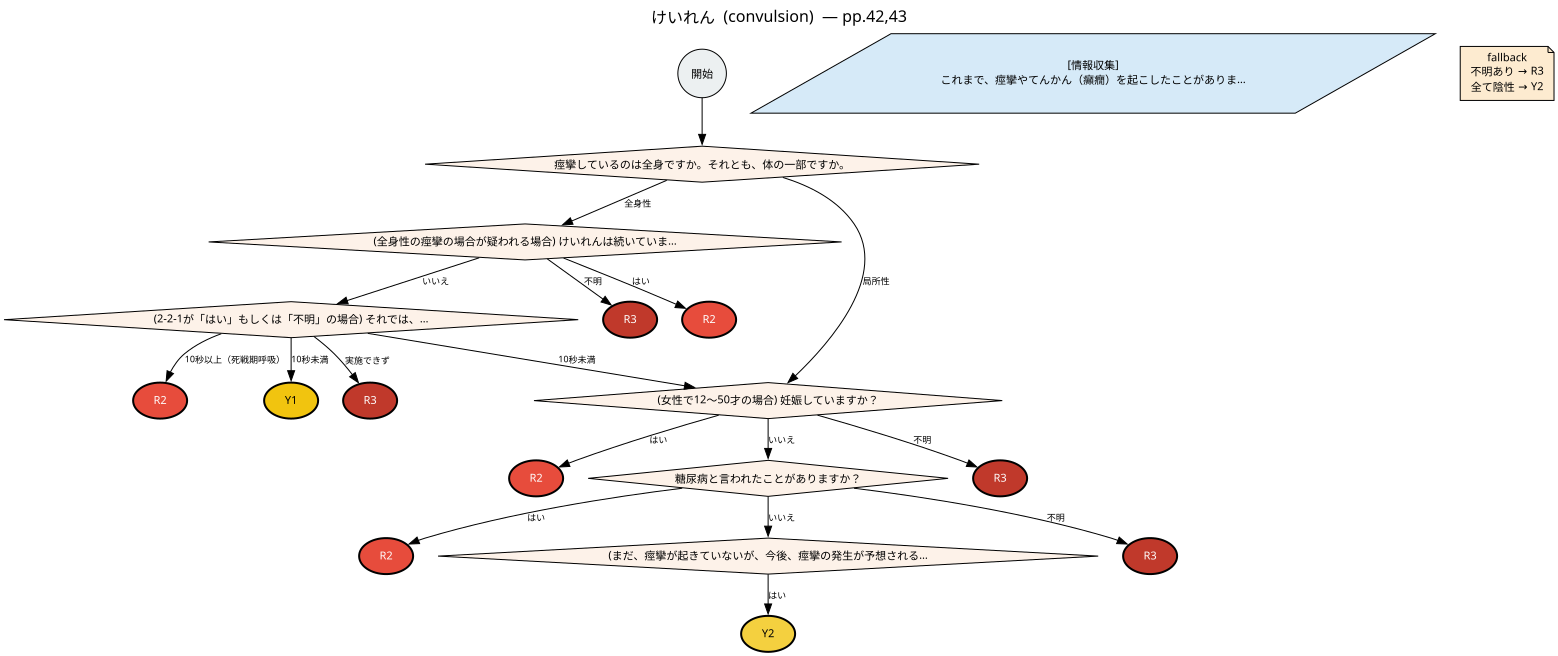

#### 頭痛 (`headache`)


(process:18060): Pango-WARNING **: 22:28:15.279: couldn't load font "Hiragino Sans Not-Rotated 16", falling back to "Sans Not-Rotated 16", expect ugly output.

(process:18060): Pango-WARNING **: 22:28:15.323: couldn't load font "Hiragino Sans Not-Rotated 11", falling back to "Sans Not-Rotated 11", expect ugly output.

(process:18060): Pango-WARNING **: 22:28:15.336: couldn't load font "Hiragino Sans Not-Rotated 9", falling back to "Sans Not-Rotated 9", expect ugly output.


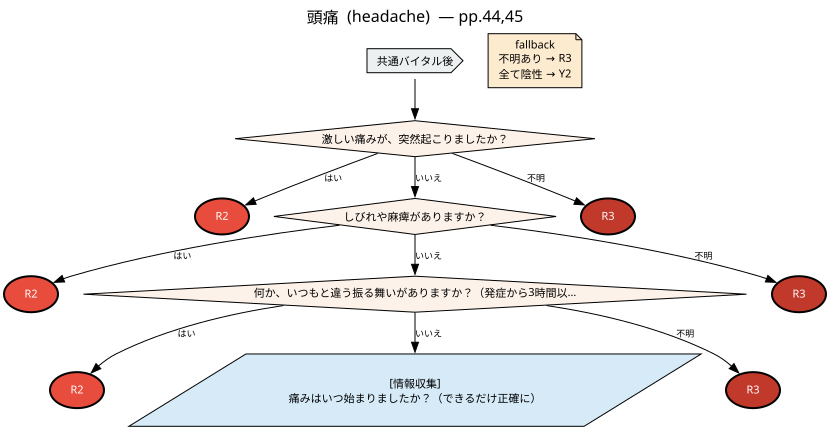

#### 胸痛（非外傷性） (`chest_pain_nontraumatic`)


(process:27384): Pango-WARNING **: 22:28:16.424: couldn't load font "Hiragino Sans Not-Rotated 16", falling back to "Sans Not-Rotated 16", expect ugly output.

(process:27384): Pango-WARNING **: 22:28:16.455: couldn't load font "Hiragino Sans Not-Rotated 11", falling back to "Sans Not-Rotated 11", expect ugly output.

(process:27384): Pango-WARNING **: 22:28:16.474: couldn't load font "Hiragino Sans Not-Rotated 9", falling back to "Sans Not-Rotated 9", expect ugly output.


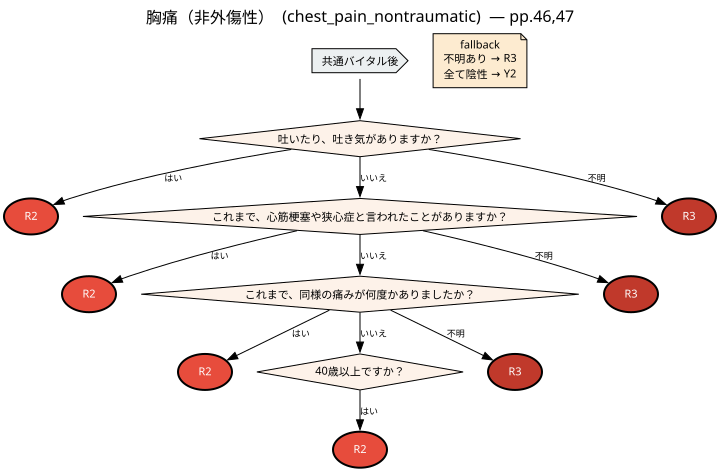

#### 背部痛 (`back_pain`)


(process:27336): Pango-WARNING **: 22:28:17.525: couldn't load font "Hiragino Sans Not-Rotated 16", falling back to "Sans Not-Rotated 16", expect ugly output.

(process:27336): Pango-WARNING **: 22:28:17.563: couldn't load font "Hiragino Sans Not-Rotated 11", falling back to "Sans Not-Rotated 11", expect ugly output.

(process:27336): Pango-WARNING **: 22:28:17.588: couldn't load font "Hiragino Sans Not-Rotated 9", falling back to "Sans Not-Rotated 9", expect ugly output.


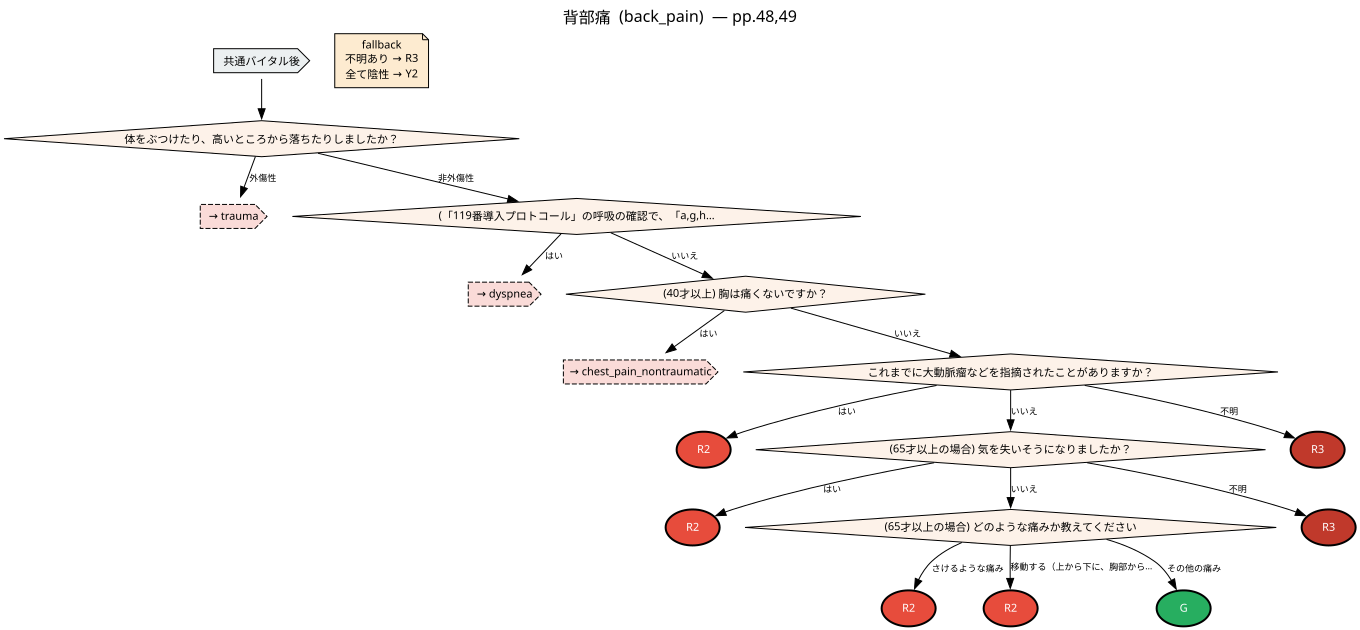

#### 腰部痛 (`lumbar_pain`)


(process:7468): Pango-WARNING **: 22:28:18.676: couldn't load font "Hiragino Sans Not-Rotated 16", falling back to "Sans Not-Rotated 16", expect ugly output.

(process:7468): Pango-WARNING **: 22:28:18.719: couldn't load font "Hiragino Sans Not-Rotated 11", falling back to "Sans Not-Rotated 11", expect ugly output.

(process:7468): Pango-WARNING **: 22:28:18.727: couldn't load font "Hiragino Sans Not-Rotated 9", falling back to "Sans Not-Rotated 9", expect ugly output.


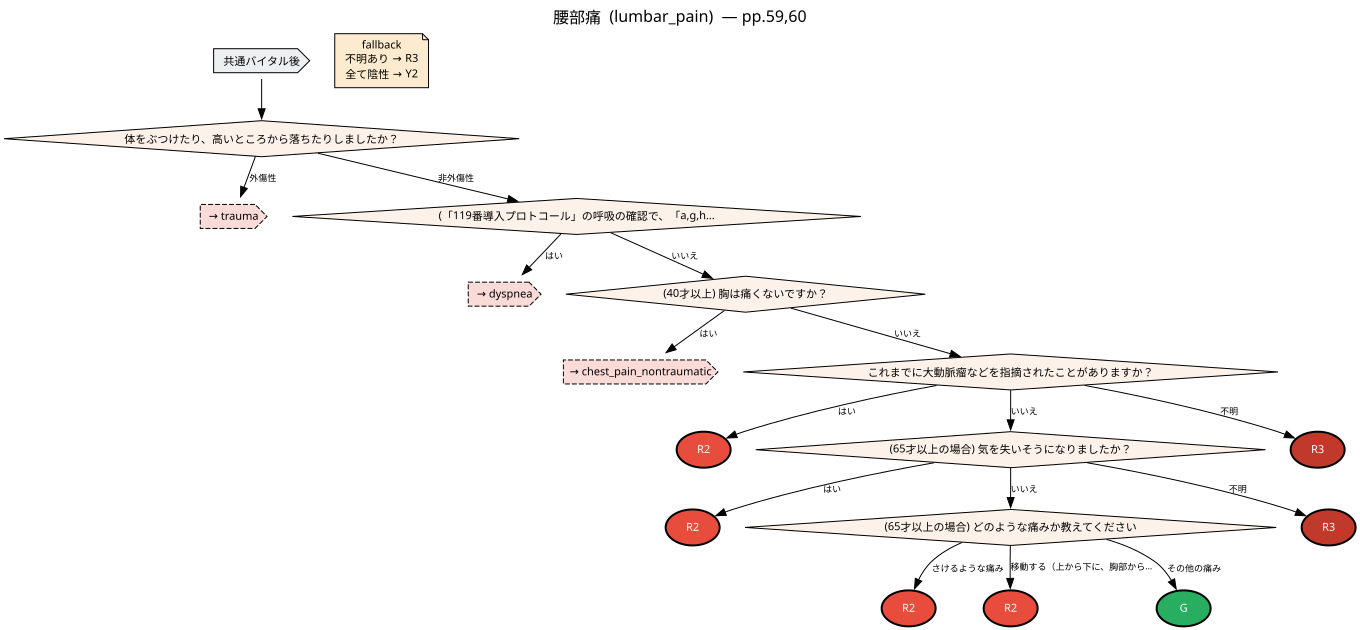

#### 成人の発熱（16歳以上） (`adult_fever`)


(process:14104): Pango-WARNING **: 22:28:19.787: couldn't load font "Hiragino Sans Not-Rotated 16", falling back to "Sans Not-Rotated 16", expect ugly output.

(process:14104): Pango-WARNING **: 22:28:19.824: couldn't load font "Hiragino Sans Not-Rotated 11", falling back to "Sans Not-Rotated 11", expect ugly output.

(process:14104): Pango-WARNING **: 22:28:19.840: couldn't load font "Hiragino Sans Not-Rotated 9", falling back to "Sans Not-Rotated 9", expect ugly output.


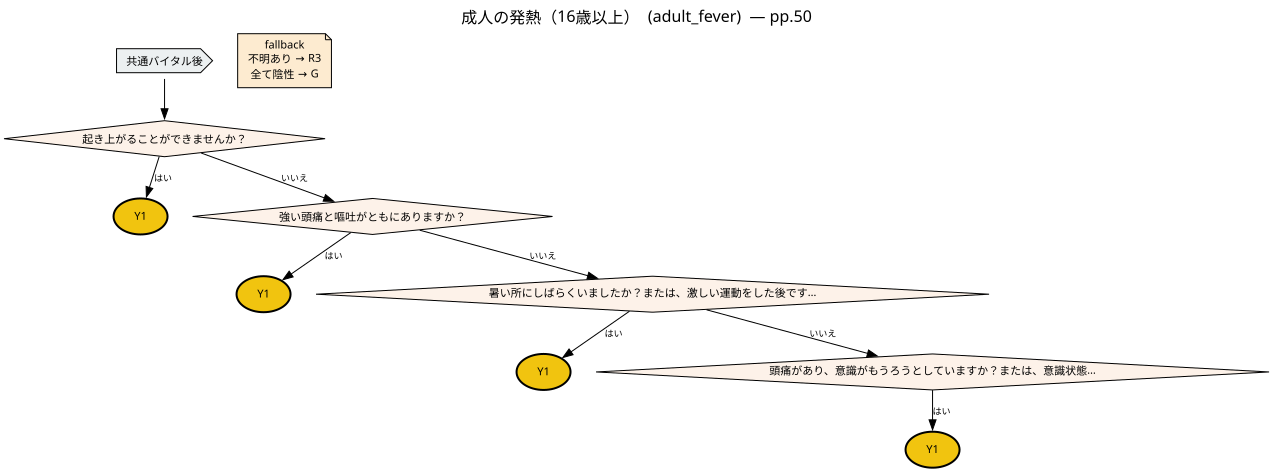

#### 腹痛 (`abdominal_pain`)


(process:22456): Pango-WARNING **: 22:28:20.825: couldn't load font "Hiragino Sans Not-Rotated 16", falling back to "Sans Not-Rotated 16", expect ugly output.

(process:22456): Pango-WARNING **: 22:28:20.868: couldn't load font "Hiragino Sans Not-Rotated 11", falling back to "Sans Not-Rotated 11", expect ugly output.

(process:22456): Pango-WARNING **: 22:28:20.883: couldn't load font "Hiragino Sans Not-Rotated 9", falling back to "Sans Not-Rotated 9", expect ugly output.


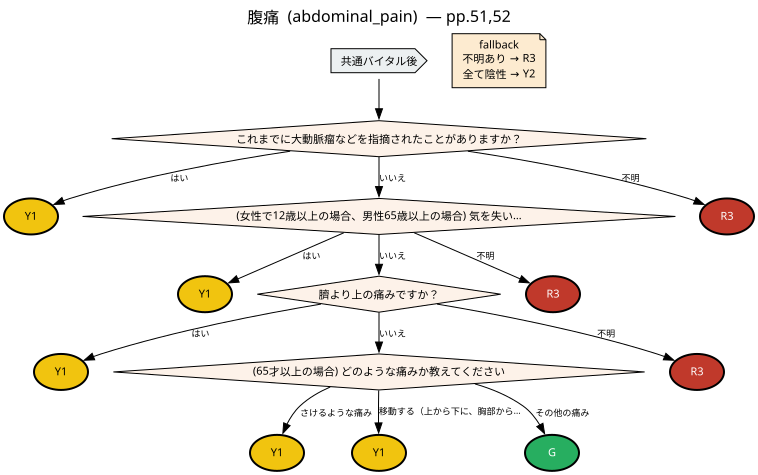

#### 成人の嘔気・嘔吐（16歳以上） (`adult_nausea_vomiting`)


(process:28816): Pango-WARNING **: 22:28:21.839: couldn't load font "Hiragino Sans Not-Rotated 16", falling back to "Sans Not-Rotated 16", expect ugly output.

(process:28816): Pango-WARNING **: 22:28:21.883: couldn't load font "Hiragino Sans Not-Rotated 11", falling back to "Sans Not-Rotated 11", expect ugly output.

(process:28816): Pango-WARNING **: 22:28:21.900: couldn't load font "Hiragino Sans Not-Rotated 9", falling back to "Sans Not-Rotated 9", expect ugly output.


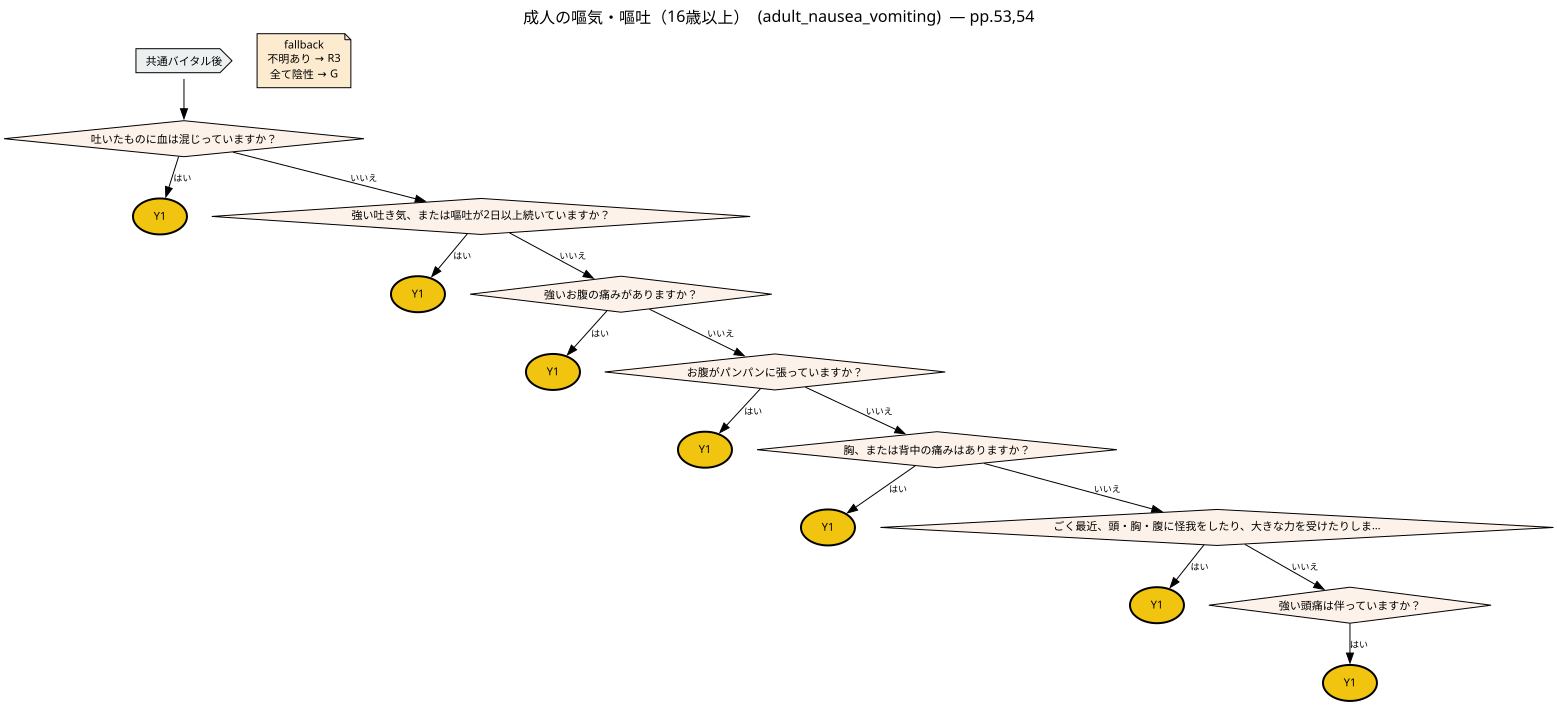

#### めまい (`dizziness`)


(process:34172): Pango-WARNING **: 22:28:22.793: couldn't load font "Hiragino Sans Not-Rotated 16", falling back to "Sans Not-Rotated 16", expect ugly output.

(process:34172): Pango-WARNING **: 22:28:22.825: couldn't load font "Hiragino Sans Not-Rotated 11", falling back to "Sans Not-Rotated 11", expect ugly output.

(process:34172): Pango-WARNING **: 22:28:22.854: couldn't load font "Hiragino Sans Not-Rotated 9", falling back to "Sans Not-Rotated 9", expect ugly output.


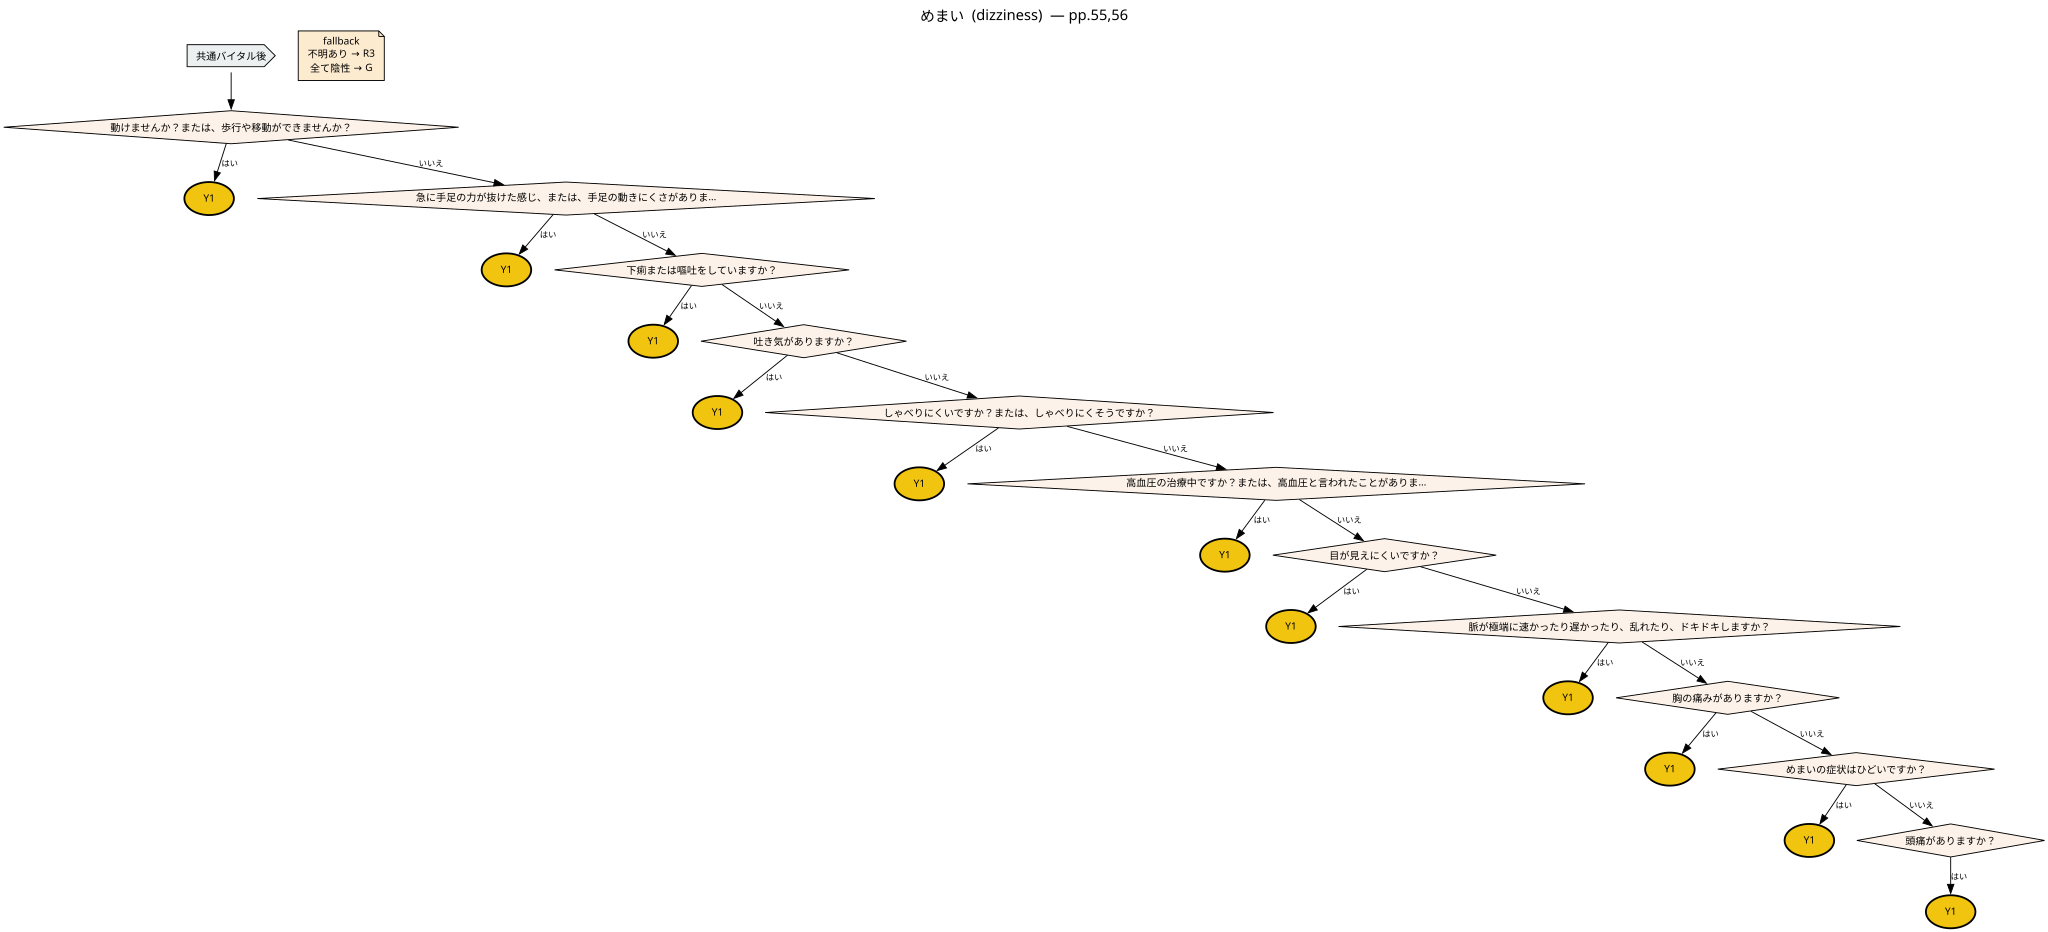

#### しびれ (`numbness`)


(process:22240): Pango-WARNING **: 22:28:23.921: couldn't load font "Hiragino Sans Not-Rotated 16", falling back to "Sans Not-Rotated 16", expect ugly output.

(process:22240): Pango-WARNING **: 22:28:23.969: couldn't load font "Hiragino Sans Not-Rotated 11", falling back to "Sans Not-Rotated 11", expect ugly output.

(process:22240): Pango-WARNING **: 22:28:23.988: couldn't load font "Hiragino Sans Not-Rotated 9", falling back to "Sans Not-Rotated 9", expect ugly output.


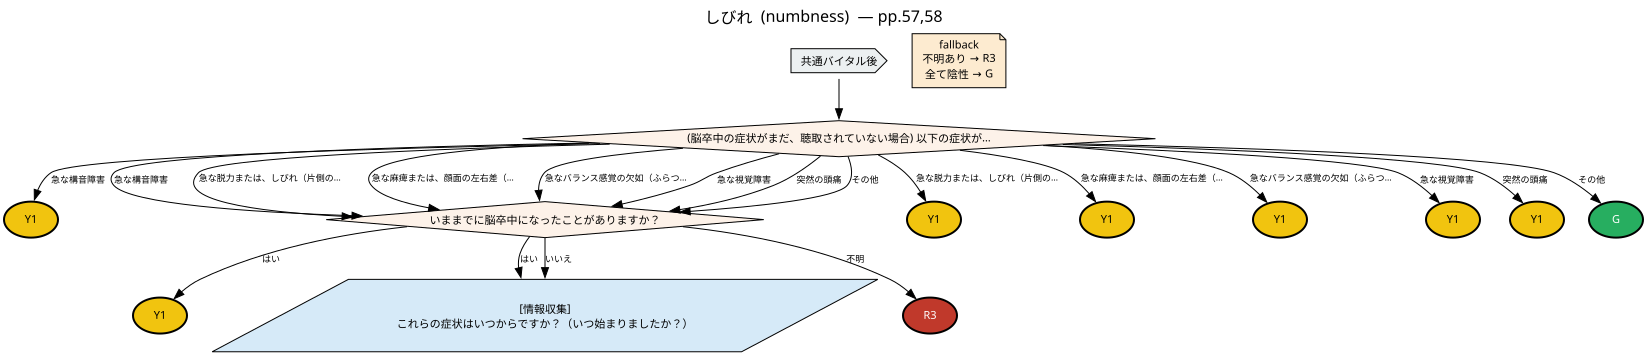

#### 吐血・喀血 (`hematemesis_hemoptysis`)


(process:31416): Pango-WARNING **: 22:28:24.969: couldn't load font "Hiragino Sans Not-Rotated 16", falling back to "Sans Not-Rotated 16", expect ugly output.

(process:31416): Pango-WARNING **: 22:28:25.007: couldn't load font "Hiragino Sans Not-Rotated 11", falling back to "Sans Not-Rotated 11", expect ugly output.

(process:31416): Pango-WARNING **: 22:28:25.020: couldn't load font "Hiragino Sans Not-Rotated 9", falling back to "Sans Not-Rotated 9", expect ugly output.


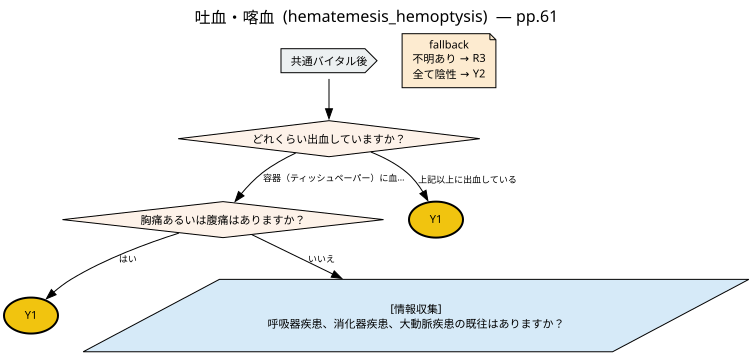

#### 下血・血便 (`melena_hematochezia`)


(process:3852): Pango-WARNING **: 22:28:25.994: couldn't load font "Hiragino Sans Not-Rotated 16", falling back to "Sans Not-Rotated 16", expect ugly output.

(process:3852): Pango-WARNING **: 22:28:26.027: couldn't load font "Hiragino Sans Not-Rotated 11", falling back to "Sans Not-Rotated 11", expect ugly output.

(process:3852): Pango-WARNING **: 22:28:26.055: couldn't load font "Hiragino Sans Not-Rotated 9", falling back to "Sans Not-Rotated 9", expect ugly output.


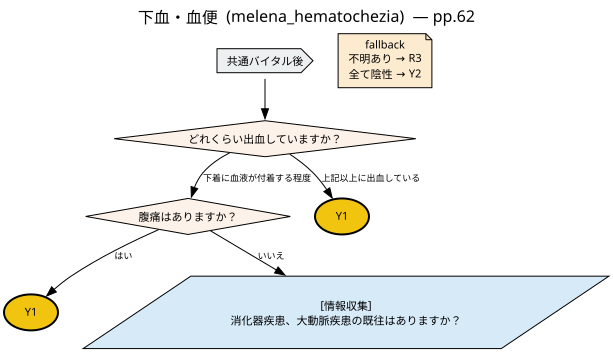

#### 具合が悪い・気分が悪い (`malaise`)


(process:15204): Pango-WARNING **: 22:28:27.329: couldn't load font "Hiragino Sans Not-Rotated 16", falling back to "Sans Not-Rotated 16", expect ugly output.

(process:15204): Pango-WARNING **: 22:28:27.360: couldn't load font "Hiragino Sans Not-Rotated 11", falling back to "Sans Not-Rotated 11", expect ugly output.

(process:15204): Pango-WARNING **: 22:28:27.386: couldn't load font "Hiragino Sans Not-Rotated 9", falling back to "Sans Not-Rotated 9", expect ugly output.


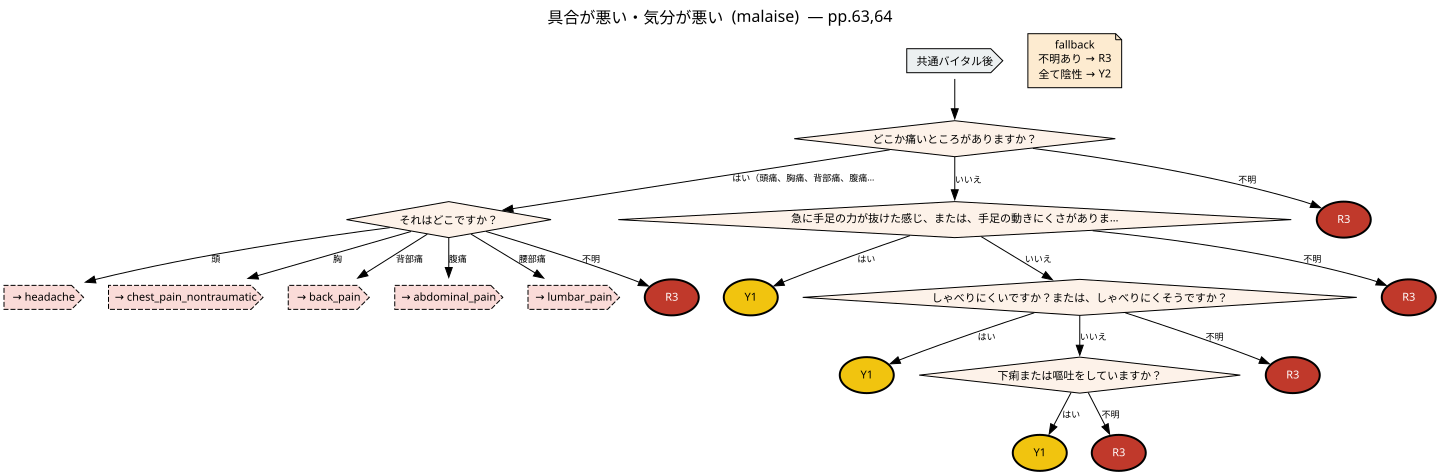

#### 外傷 (`trauma`)


(process:18992): Pango-WARNING **: 22:28:28.359: couldn't load font "Hiragino Sans Not-Rotated 16", falling back to "Sans Not-Rotated 16", expect ugly output.

(process:18992): Pango-WARNING **: 22:28:28.405: couldn't load font "Hiragino Sans Not-Rotated 11", falling back to "Sans Not-Rotated 11", expect ugly output.

(process:18992): Pango-WARNING **: 22:28:28.419: couldn't load font "Hiragino Sans Not-Rotated 9", falling back to "Sans Not-Rotated 9", expect ugly output.


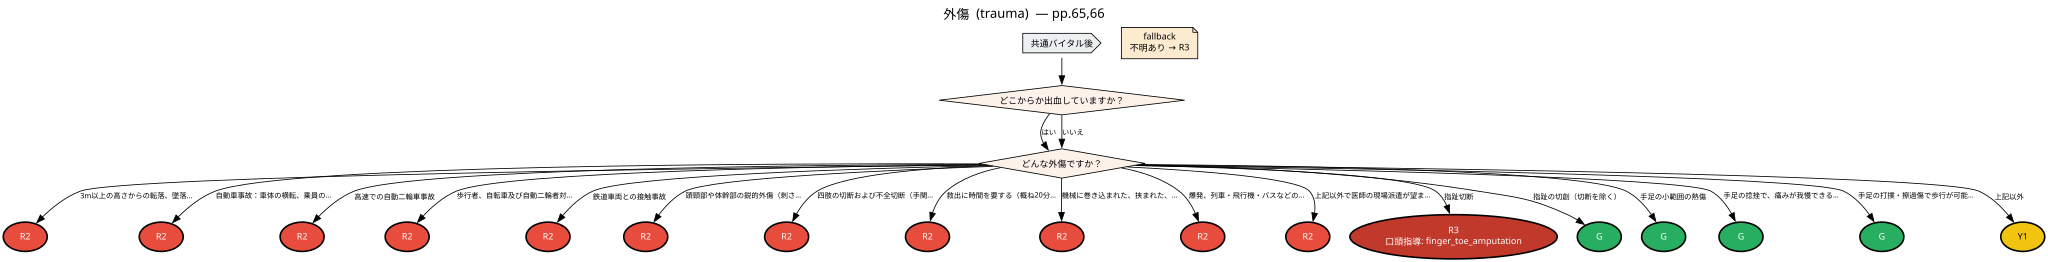

#### 固形物誤飲 (`foreign_body_ingestion`)


(process:19548): Pango-WARNING **: 22:28:29.672: couldn't load font "Hiragino Sans Not-Rotated 16", falling back to "Sans Not-Rotated 16", expect ugly output.

(process:19548): Pango-WARNING **: 22:28:29.711: couldn't load font "Hiragino Sans Not-Rotated 11", falling back to "Sans Not-Rotated 11", expect ugly output.

(process:19548): Pango-WARNING **: 22:28:29.738: couldn't load font "Hiragino Sans Not-Rotated 9", falling back to "Sans Not-Rotated 9", expect ugly output.


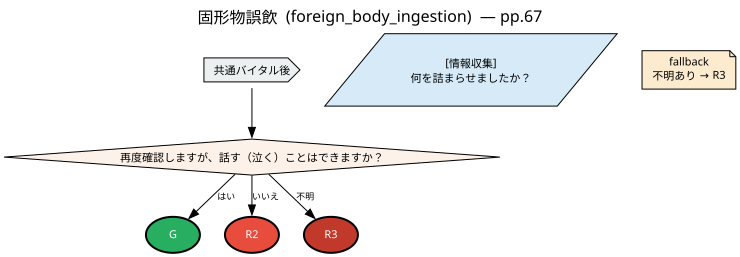

#### 中毒 (`poisoning`)


(process:22232): Pango-WARNING **: 22:28:30.721: couldn't load font "Hiragino Sans Not-Rotated 16", falling back to "Sans Not-Rotated 16", expect ugly output.

(process:22232): Pango-WARNING **: 22:28:30.761: couldn't load font "Hiragino Sans Not-Rotated 11", falling back to "Sans Not-Rotated 11", expect ugly output.

(process:22232): Pango-WARNING **: 22:28:30.773: couldn't load font "Hiragino Sans Not-Rotated 9", falling back to "Sans Not-Rotated 9", expect ugly output.


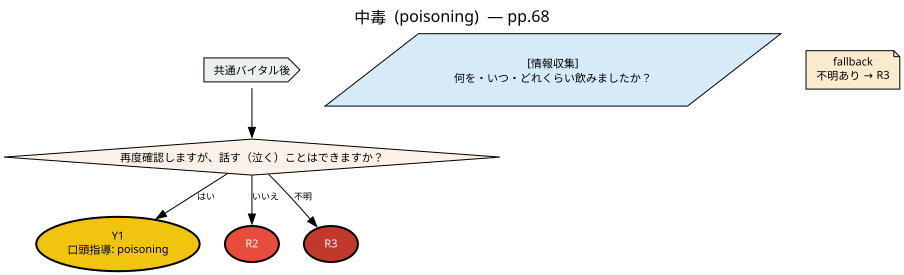

#### 小児の発熱（16歳未満） (`pediatric_fever`)


(process:27576): Pango-WARNING **: 22:28:31.829: couldn't load font "Hiragino Sans Not-Rotated 16", falling back to "Sans Not-Rotated 16", expect ugly output.

(process:27576): Pango-WARNING **: 22:28:31.873: couldn't load font "Hiragino Sans Not-Rotated 11", falling back to "Sans Not-Rotated 11", expect ugly output.

(process:27576): Pango-WARNING **: 22:28:31.934: couldn't load font "Hiragino Sans Not-Rotated 9", falling back to "Sans Not-Rotated 9", expect ugly output.


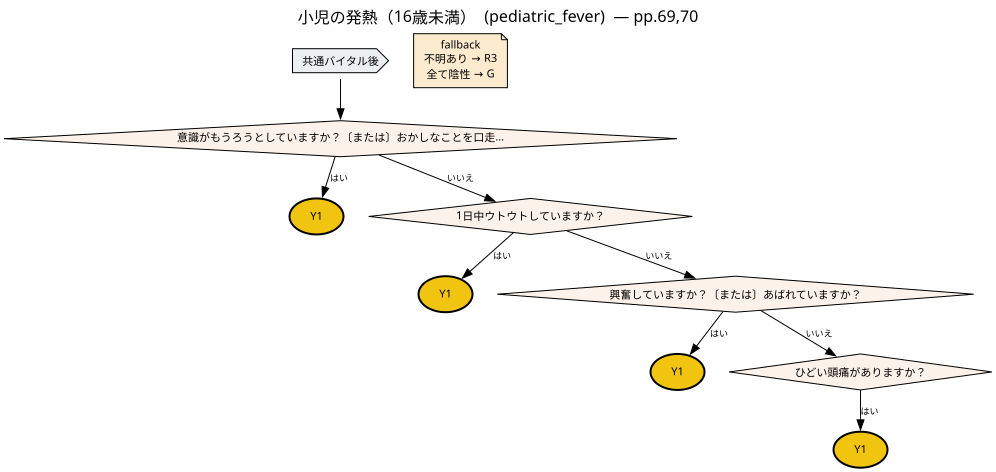

#### 小児の嘔気・嘔吐（16歳未満） (`pediatric_nausea_vomiting`)


(process:22332): Pango-WARNING **: 22:28:32.910: couldn't load font "Hiragino Sans Not-Rotated 16", falling back to "Sans Not-Rotated 16", expect ugly output.

(process:22332): Pango-WARNING **: 22:28:32.945: couldn't load font "Hiragino Sans Not-Rotated 11", falling back to "Sans Not-Rotated 11", expect ugly output.

(process:22332): Pango-WARNING **: 22:28:32.976: couldn't load font "Hiragino Sans Not-Rotated 9", falling back to "Sans Not-Rotated 9", expect ugly output.


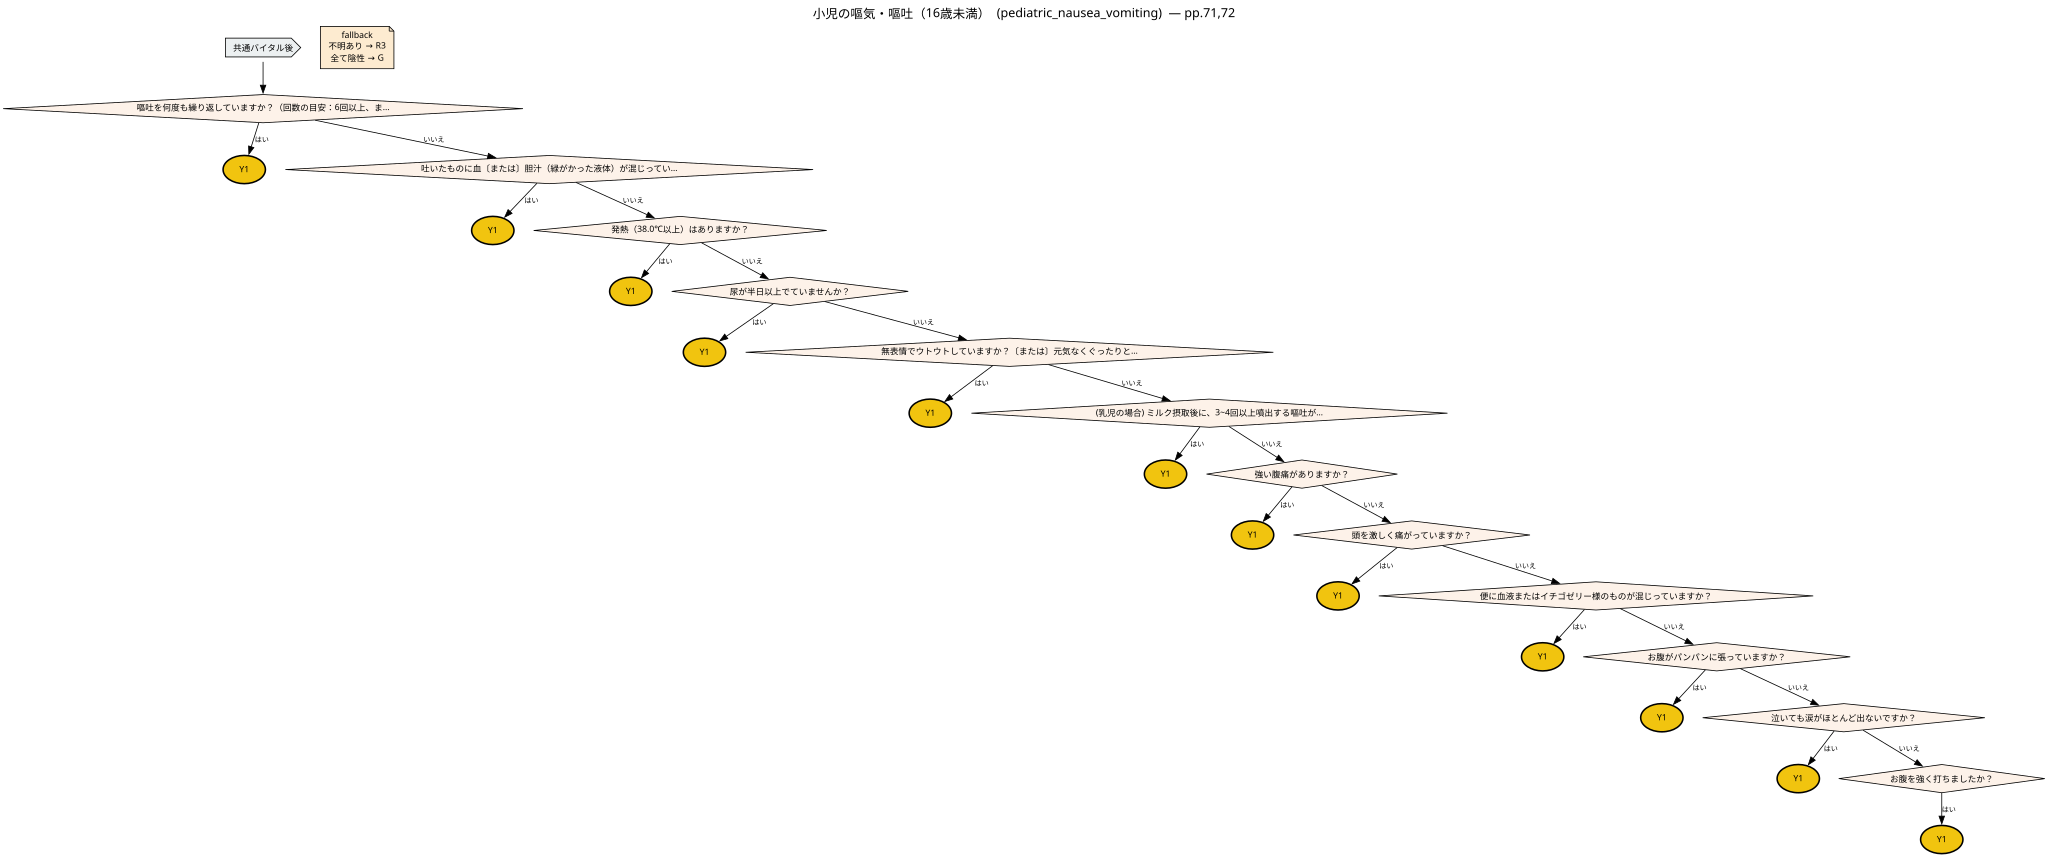

#### 小児の頭・頸部外傷（16歳未満） (`pediatric_head_neck_trauma`)


(process:36548): Pango-WARNING **: 22:28:34.308: couldn't load font "Hiragino Sans Not-Rotated 16", falling back to "Sans Not-Rotated 16", expect ugly output.

(process:36548): Pango-WARNING **: 22:28:34.346: couldn't load font "Hiragino Sans Not-Rotated 11", falling back to "Sans Not-Rotated 11", expect ugly output.

(process:36548): Pango-WARNING **: 22:28:34.373: couldn't load font "Hiragino Sans Not-Rotated 9", falling back to "Sans Not-Rotated 9", expect ugly output.


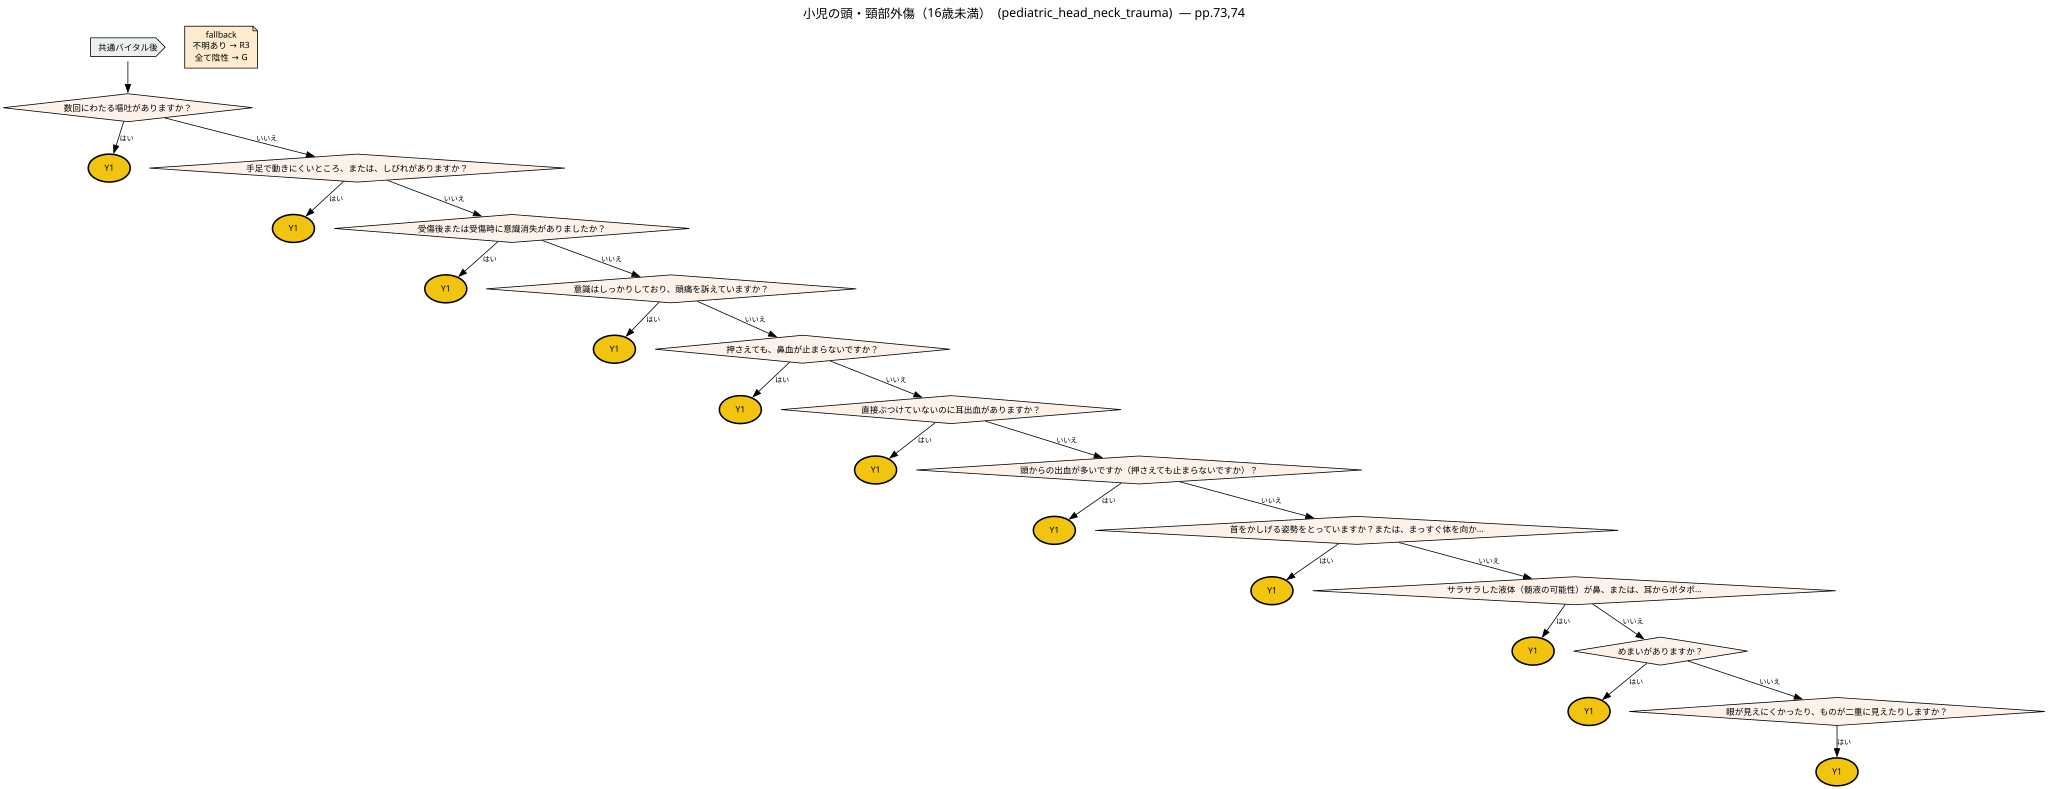

In [14]:
for pid, proto in protocols.items():
    display(Markdown(f"#### {proto.get('name', pid)} (`{pid}`)"))
    display(render_protocol(pid))

## 6. ファイル保存（任意）

SVG と PDF を `graphviz_diagrams/` に書き出します。

In [15]:
OUT_DIR = Path("graphviz_diagrams")
OUT_DIR.mkdir(exist_ok=True)

render_common_flow().render(OUT_DIR / "00_common_flow", format="svg", cleanup=True)
render_router().render(OUT_DIR / "01_router", format="svg", cleanup=True)

for i, pid in enumerate(protocols, start=2):
    render_protocol(pid).render(OUT_DIR / f"{i:02d}_{pid}", format="svg", cleanup=True)

print(f"saved to {OUT_DIR.resolve()}")


(process:33928): Pango-WARNING **: 22:28:35.492: couldn't load font "Hiragino Sans Not-Rotated 16", falling back to "Sans Not-Rotated 16", expect ugly output.

(process:33928): Pango-WARNING **: 22:28:35.538: couldn't load font "Hiragino Sans Not-Rotated 11", falling back to "Sans Not-Rotated 11", expect ugly output.

(process:33928): Pango-WARNING **: 22:28:35.609: couldn't load font "Hiragino Sans Not-Rotated 9", falling back to "Sans Not-Rotated 9", expect ugly output.

(process:21292): Pango-WARNING **: 22:28:36.957: couldn't load font "Hiragino Sans Not-Rotated 16", falling back to "Sans Not-Rotated 16", expect ugly output.

(process:21292): Pango-WARNING **: 22:28:36.986: couldn't load font "Hiragino Sans Not-Rotated 11", falling back to "Sans Not-Rotated 11", expect ugly output.

(process:21292): Pango-WARNING **: 22:28:37.003: couldn't load font "Hiragino Sans Not-Rotated 9", falling back to "Sans Not-Rotated 9", expect ugly output.

(process:33588): Pango-WARNING **: 22:28:39

saved to C:\Users\hiyok\Desktop\Emergency_task\transition_diagram\graphviz_diagrams
